# Mini Project - IronKaggle: King County House Prices

## Overview & Objective

* Your mission is to delve into a dataset of house sale prices for King County, including Seattle, spanning one year from May 2014 to May 2015. This project encompasses various computational tasks such as data loading, visualization, calculating returns, and portfolio analysis, tailored to the real estate domain. It aims to enhance your Python skills, deepen your understanding of real estate financial data, and hone your analytical prowess. Are you ready to embark on this analytical journey through the housing market?

* This notebook builds an end-to-end machine learning workflow to predict house sale prices and analyze high-value properties (price >= $650,000).

* Algorithms included from the ensemble lessons:
- Random Forest Regressor
- Gradient Boosting Regressor
- AdaBoost Regressor

## About the Data:

* This dataset comprises one-year data (from May 2014 to May 2015) of house sale prices across King County, including Seattle. It features 21 different columns, providing a comprehensive overview of the real estate market:

* id: A unique identifier for a house.
* date: The date on which the house was sold.
* price: The sale price of the house (prediction target).
* bedrooms: Number of bedrooms in the house.
* bathrooms: Number of bathrooms in the house, per bedroom.
* sqft_living: Square footage of the interior living space.
* sqft_lot: Square footage of the land space.
* floors: Number of floors (levels) in the house.
* waterfront: Whether the house has a waterfront view.
* view: Number of times the house has been viewed.
* condition: The overall condition of the house.
* grade: The overall grade given to the house, based on the King County grading system.
* sqft_above: Square footage of the house apart from the basement.
* sqft_basement: Square footage of the basement.
* yr_built: The year the house was built.
* yr_renovated: The year the house was renovated.
* zipcode: ZIP code area.
* lat: Latitude coordinate.
* long: Longitude coordinate.
* sqft_living15: The interior living space for the nearest 15 neighbors in 2015.
* sqft_lot15: The land spaces for the nearest 15 neighbors in 2015.
* **TARGET** --> **Price**: Our primary focus is to understand which features most significantly impact the house price. 

## 1. Imports and Setup

In [112]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor


import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data

In [113]:
# Download latest version
path = kagglehub.dataset_download("minasameh55/king-country-houses-aa")
print(os.listdir(path)) #this helps understand what's inside the directory

file_path = os.path.join(path, "king_ country_ houses_aa.csv")
df = pd.read_csv(file_path)

print("Path to dataset files:", path)
print("First 10 records:\n")
df.head(10)


['king_ country_ houses_aa.csv']
Path to dataset files: C:\Users\ranik\.cache\kagglehub\datasets\minasameh55\king-country-houses-aa\versions\1
First 10 records:



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


**Dataset Overview**

The dataset contains **21,613 house sale records** across 21 columns spanning May 2014 – May 2015 in King County, Washington. Each row is a unique transaction. The target variable is `price` (continuous), which we will predict using the remaining 20 columns as potential features. The initial `df.head()` confirms the data loaded correctly and gives a first look at the range of values — prices vary from the low $100Ks to well over $1M in just the first five rows, signalling high variance in the target.

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

**Structure Interpretation**

`df.info()` reveals several important details:
- **No null values** — all 21,613 rows have complete data across all 21 columns, so imputation is not required.
- **Mixed dtypes** — most columns are numeric (`int64` / `float64`), but `date` is stored as a plain string (`str`), meaning it needs parsing before any time-based analysis.
- `zipcode` is typed as `int64`, which is misleading — zip codes are categorical identifiers, not ordinal numbers. We will convert it to a string before encoding.
- `id` is a row identifier with no predictive value and must be dropped before modeling.

In [115]:
# Missing value and duplicate check
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nBasic statistics:")
df.describe().T

=== Missing Values ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Total missing: 0

Duplicate rows: 0

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


**Data Quality Findings**

The null check confirms the dataset is **complete** — zero missing values in any column and zero duplicate rows. This is unusually clean for real-world data and means we can proceed directly to feature engineering without any imputation or deduplication steps. The `describe()` output gives early statistical signals:
- `price` has a large standard deviation relative to its mean, confirming high spread and likely right-skew.
- `bedrooms` contains at least one extreme value.
- `yr_renovated` is mostly 0, meaning most homes have never been renovated — this column has very low density of non-zero values and may need special treatment (e.g., binary flag).

## 3. Data Cleaning and Feature Engineering

- Dropping id, date, zipcode:
the decision to drop those columns is due to the fact that id is an identifiier witch doesn't give much information, date has been splitted into two nwe columns to retrieve year and month and zipcode can be approximated throu latitude and longitude

In [116]:
df_model = df.copy()

# Parse date and add useful date-based features
df_model["date"] = pd.to_datetime(df_model["date"], format="%Y%m%dT%H%M%S")
df_model["sale_year"] = df_model["date"].dt.year
df_model["sale_month"] = df_model["date"].dt.month

df_model = df_model[df_model['bedrooms'] < 33]

# Convert selected columns to categorical/string for consistent encoding
# df_model["zipcode"] = df_model["zipcode"].astype(str)

# Keep id only for reference, do not use as predictor
df_model = df_model.drop(columns=["id", "date",'zipcode'])

print(df_model.shape)
df_model.head()
df_model["bedrooms"].describe()

(21612, 20)


count    21612.000000
mean         3.369471
std          0.907982
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         11.000000
Name: bedrooms, dtype: float64

**Feature Engineering Decisions**

Three deliberate choices are made here:

1. **Date parsing → `sale_year` + `sale_month`**: The raw `date` string carries temporal information the model can use (e.g., seasonality in housing markets). Splitting it into two numeric components lets tree-based models use the signal without needing any further transformation.

2. **Drop `id`,`date`,`zipcode`**: `id` is an arbitrary unique identifier with no relationship to price. Keeping it would either be ignored by the model or, worse, memorized as a spurious pattern. The original `date` column is dropped after extracting its useful components. `zipcode` is dropped because we can use longitude and latitude to give information about the position of the houses

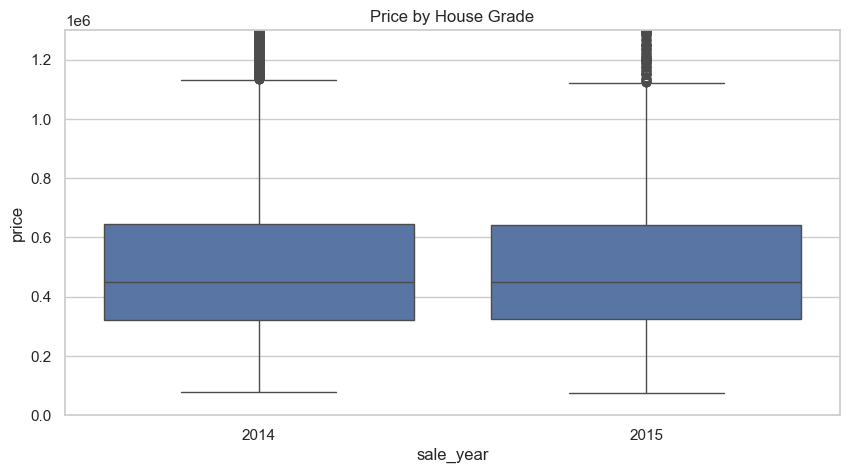

In [117]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="sale_year", y="price")
plt.ylim(0,1300000)
plt.title("Price by House Grade")
plt.xticks(rotation=0)
plt.show()

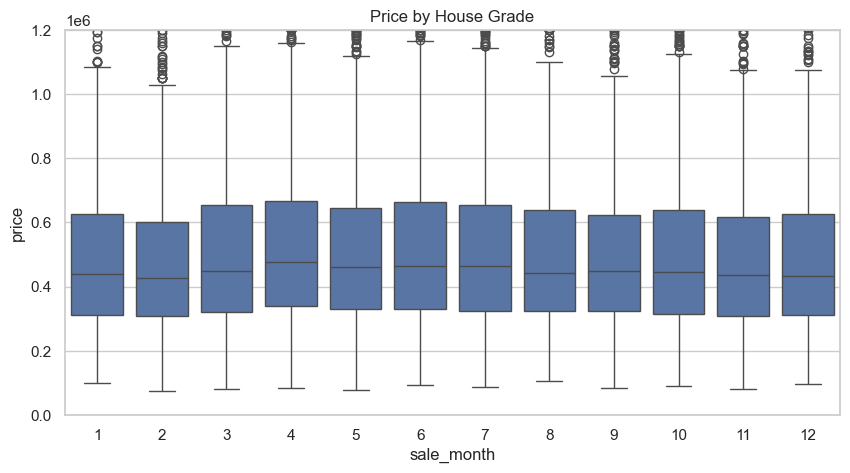

In [118]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="sale_month", y="price")
plt.ylim(0,1200000)
plt.title("Price by House Grade")
plt.xticks(rotation=0)
plt.show()

In [119]:
month_price_description = round(df_model[['sale_month','price']].groupby('sale_month')['price'].describe(),2)
# Display the result
month_price_description

,count,mean,std,min,25%,50%,75%,max
sale_month,,,,,,,,
1,978.0,525870.89,366053.60,99000.0,310162.50,438500.0,625000.0,3567000.0
2,1250.0,507851.37,325998.28,75000.0,309000.00,425545.0,600000.0,3065000.0
3,1875.0,543977.19,355051.20,81000.0,319925.00,450000.0,655000.0,3395000.0
4,2231.0,561837.77,369928.88,84000.0,338450.00,476500.0,668250.0,5350000.0
5,2414.0,550768.79,372941.57,78000.0,330000.00,462000.0,646625.0,4208000.0
6,2179.0,557964.57,388345.28,92000.0,330000.00,465000.0,665000.0,7062500.0
7,2211.0,544788.76,346731.12,86500.0,325000.00,465000.0,653875.0,3800000.0
8,1940.0,536445.28,370583.43,107000.0,324560.25,442100.0,640000.0,5570000.0
9,1774.0,529253.82,372531.67,85000.0,325000.00,450000.0,624375.0,6885000.0


looking at the distribution of the house prices grouped per year and month we don't see a strong relationship between time periods and prices, we're going to later confirm absence of seasonality through the correlation matrix

## 4. Exploratory Data Analysis

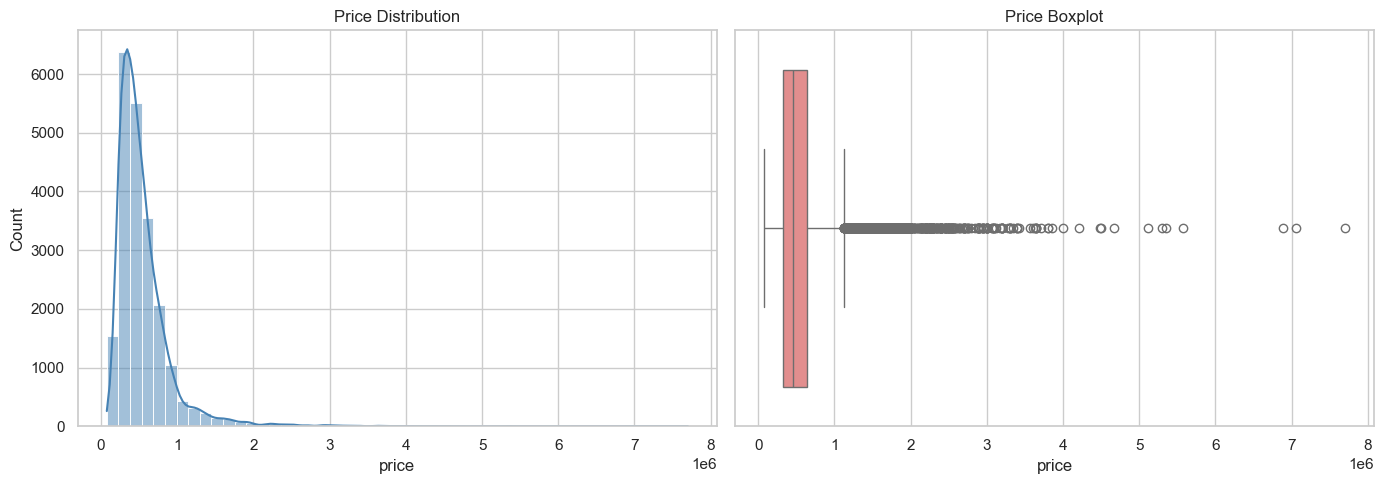

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model["price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution")

sns.boxplot(x=df_model["price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Price Boxplot")

plt.tight_layout()
plt.show()

**Price Distribution Interpretation**

The histogram reveals a strong **right-skew**: the bulk of sales cluster between $200K–$700K, but a long tail extends to $7.7M. The KDE curve reinforces this — the peak (mode) is well below the mean. The boxplot makes the outlier situation concrete: the whiskers extend to roughly $1.1M, and every point beyond that is flagged as an outlier, representing genuine luxury sales, not data errors.

**Implication for modeling**: right-skewed targets can inflate RMSE because large errors on high-value homes are squared. A log-transform on `price` could normalize the distribution and produce better-calibrated predictions, though it adds complexity in interpreting the output. For this project we model on the raw scale and accept that RMSE will be dominated by the upper tail.

### Check collinearity

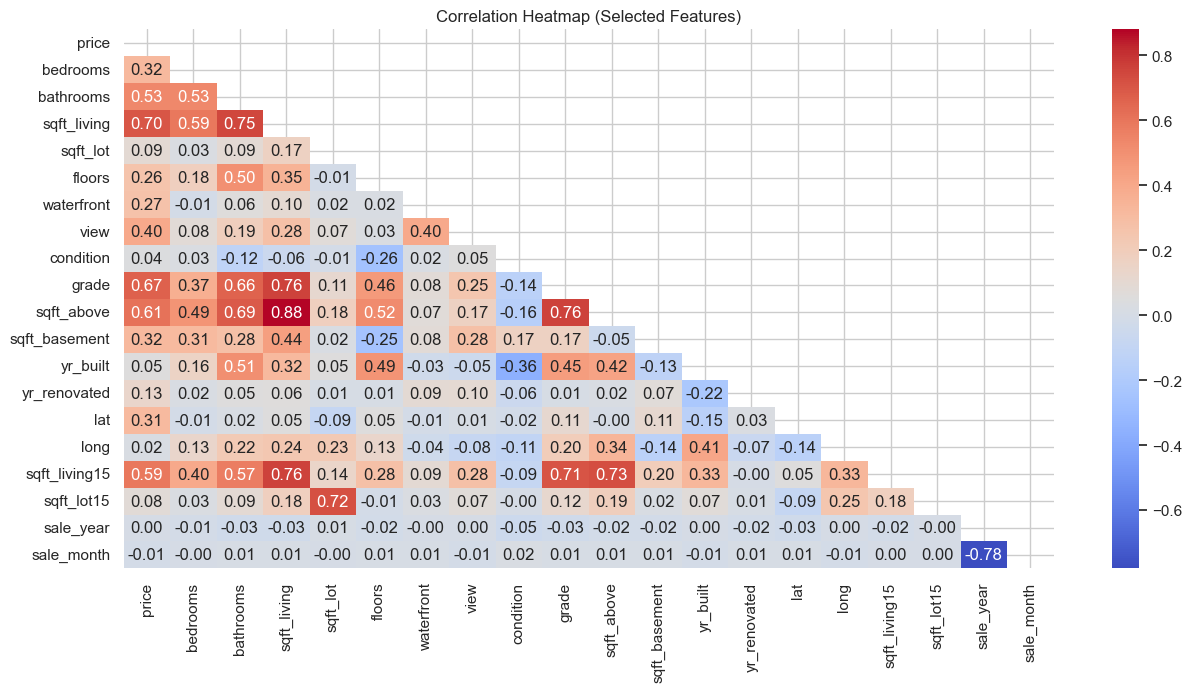

In [121]:
corr_cols = df_model.columns

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [122]:
df_model = df_model.drop(columns=[ "sale_year",'sale_month'])

In [123]:
df_model.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

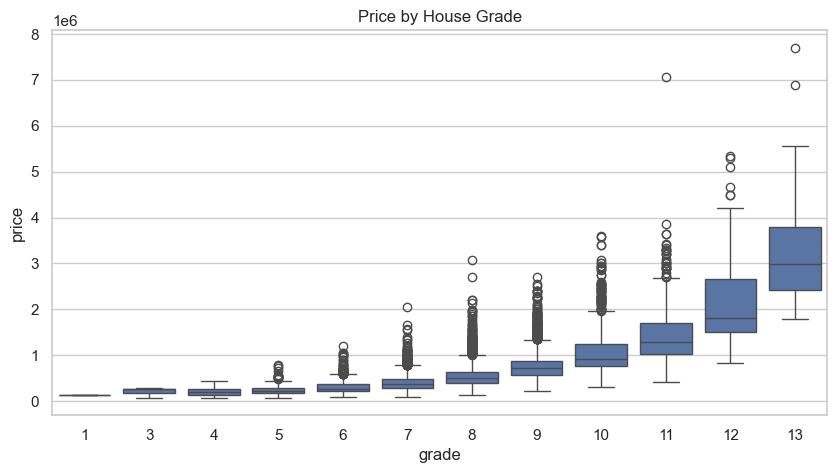

In [124]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="grade", y="price")
plt.title("Price by House Grade")
plt.xticks(rotation=0)
plt.show()

In [125]:
grade_price_description = round(df_model[['grade','price']].groupby('grade')['price'].describe(),2)
# Display the result
grade_price_description

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
1,1.0,142000.00,NaN,142000.0,142000.0,142000.0,142000.0,142000.0
3,3.0,205666.67,113517.99,75000.0,168500.0,262000.0,271000.0,280000.0
4,29.0,214381.03,94306.17,80000.0,145000.0,205000.0,265000.0,435000.0
5,242.0,248523.97,118100.28,78000.0,175000.0,228700.0,295750.0,795000.0
6,2038.0,301919.64,122970.28,82000.0,215037.5,275276.5,366837.5,1200000.0
7,8980.0,402563.82,155865.46,90000.0,285000.0,375000.0,485000.0,2050000.0
8,6068.0,542852.77,217473.37,140000.0,390000.0,510000.0,640000.0,3070000.0
9,2615.0,773513.19,316120.08,230000.0,571500.0,720000.0,880000.0,2700000.0
10,1134.0,1071771.07,483545.09,316000.0,768087.5,914327.0,1250000.0,3600000.0


**Price by Grade Interpretation**

The King County grading system scores homes from 1–13 based on construction quality and design. The boxplot shows a **clear, near-monotonic relationship**: median price rises steadily with each grade step. Key observations:
- Grades 1–5 are rare and very low-priced (minimal samples).
- The sharpest jump occurs between grades 12 and 13, where the median price roughly doubles.
- Grade 13 homes have enormous spread — they include a small number of ultra-luxury estates with wildly varying prices, driving large interquartile ranges.

This confirms `grade` will be among the most predictive features in any model trained on this data.

**Correlation Heatmap Interpretation**

The heatmap quantifies linear relationships between `price` and selected features. Top takeaways:
- **`sqft_living` (0.70)** — the single strongest individual predictor. Larger homes command higher prices almost linearly.
- **`grade` (0.67)** — construction quality is the second most correlated attribute, confirming the grade boxplot pattern.
- **`sqft_above` and `sqft_living15`** are both highly correlated with `sqft_living` (~0.87–0.88), indicating multicollinearity. Tree-based models handle this naturally, but it would be a concern for linear regression.
- **`lat` (0.31)** — latitude captures a north-south geographic price gradient across King County.
- **`bedrooms`** has a surprisingly low correlation (0.31) — more bedrooms does not reliably mean higher price once living area is accounted for.
- **`sale_month`** has a surprisingly low correlation (0.31) — more bedrooms does not reliably mean higher price once living area is accounted for.

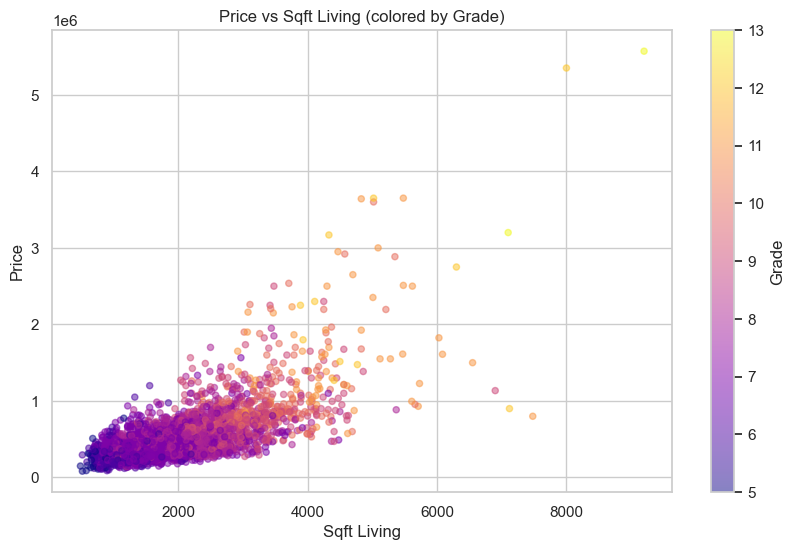

In [126]:
# Price vs sqft_living with grade as hue
plt.figure(figsize=(10, 6))
scatter_sample = df_model.sample(3000, random_state=RANDOM_STATE)
sc = plt.scatter(
    scatter_sample["sqft_living"],
    scatter_sample["price"],
    c=scatter_sample["grade"],
    cmap="plasma",
    alpha=0.5,
    s=20
)
plt.colorbar(sc, label="Grade")
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Price vs Sqft Living (colored by Grade)")
plt.show()

**Price vs Sqft Living (with Grade) Interpretation**

Adding `grade` as color reveals an important **interaction effect**: for the same living area, higher-grade homes (brighter/yellow on the plasma scale) command significantly higher prices. Two homes with identical square footage can differ by hundreds of thousands of dollars depending on construction quality. This non-linear, interaction-driven behavior is exactly where ensemble methods like Random Forest and Gradient Boosting excel over a simple linear regression, which cannot capture such conditional relationships without explicit feature engineering.

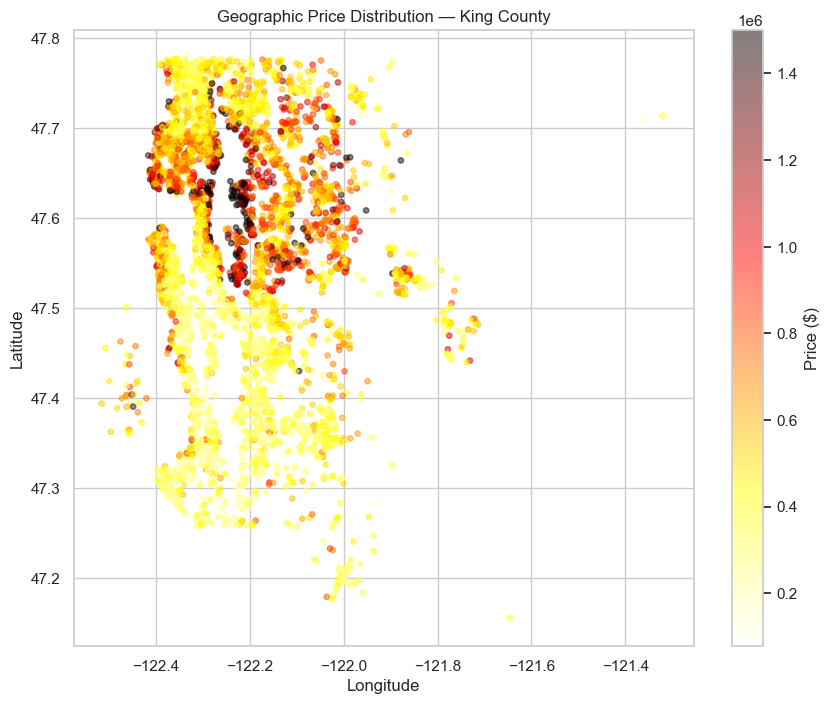

In [127]:
# Geographic price map — latitude vs longitude colored by price

plt.figure(figsize=(10, 8))
geo_sample = df_model.sample(5000, random_state=RANDOM_STATE)
sc = plt.scatter(
    geo_sample["long"],
    geo_sample["lat"],
    c=geo_sample["price"],
    cmap="hot_r",
    alpha=0.5,
    s=15,
    vmax=1_500_000
)
plt.colorbar(sc, label="Price ($)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Price Distribution — King County")
plt.show()

**Geographic Price Distribution Interpretation**

The map plots each property by its GPS coordinates, colored by sale price (darker = cheaper, brighter/hotter = more expensive). Clear spatial clusters emerge:
- **High-price hotspots** appear near the Lake Washington shoreline (east side of Seattle) and parts of north Seattle — areas known for waterfront access, views, and affluent neighborhoods.
- **Lower-price areas** are distributed across the south and southeast portions of the county.
- The color gradient is highly non-linear in space, meaning **location is a complex, non-linear predictor**. Latitude and longitude individually only partially capture this; zip codes serve as a proxy for neighborhood effects and will be more informative once one-hot encoded.

This visualization justifies keeping both lat/long and zipcode in the feature set — they capture overlapping but distinct aspects of location.

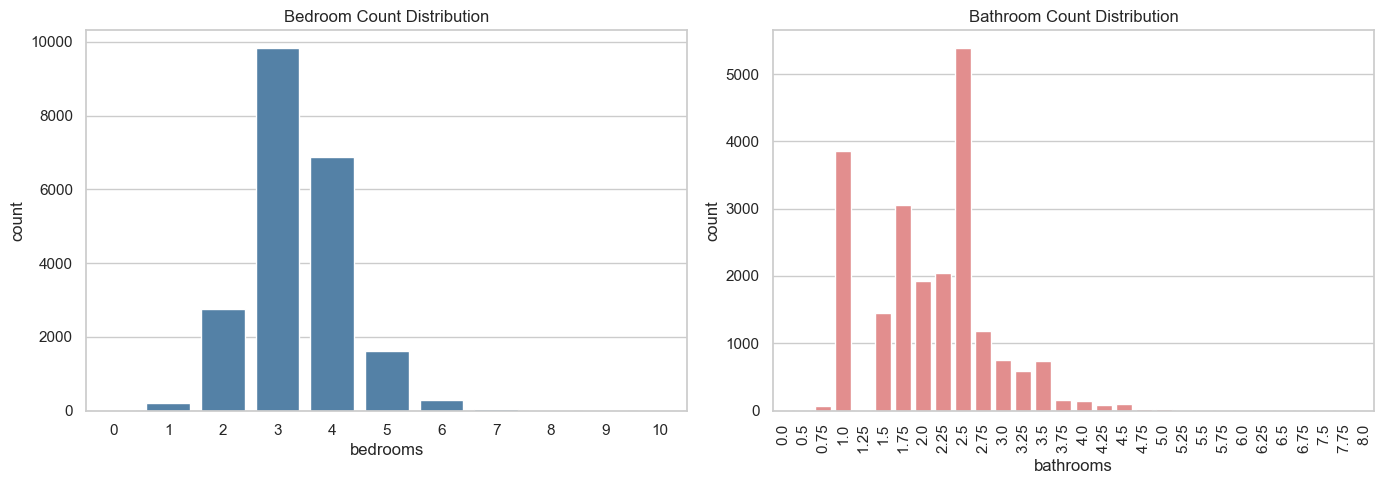

In [128]:
# Distribution of bedrooms and bathrooms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_model[df_model["bedrooms"] <= 10], x="bedrooms", ax=axes[0], color="steelblue")
axes[0].set_title("Bedroom Count Distribution")

sns.countplot(data=df_model, x="bathrooms", ax=axes[1], color="lightcoral", order=sorted(df_model["bathrooms"].unique()))
axes[1].set_title("Bathroom Count Distribution")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Bedroom & Bathroom Distribution Interpretation**

- **Bedrooms**: The market is dominated by 3–4 bedroom homes, which represent the typical family home profile. Properties with 6+ bedrooms are rare (< 1% of listings), and anything above 8 should be considered an extreme outlier — one record has 33 bedrooms, which is almost certainly a data entry error.
- **Bathrooms**: The distribution is more spread and fractional (e.g., 2.25, 2.75) because King County counts bathrooms in partial increments (a half bath has a toilet and sink; a three-quarter bath adds a shower). The most common count is 2.5, typical of a mid-size family home.

Understanding these distributions sets realistic expectations: our model needs to perform well on 3–4 bed / 2–3 bath homes above all, since that is where the majority of test predictions will fall.

## 5. Focus Segment: Houses Priced at $650K and Above

In [129]:
high_value = df_model[df_model["price"] >= 650000].copy()

print(f"High-value properties: {high_value.shape[0]} rows ({high_value.shape[0] / df_model.shape[0]:.2%} of dataset)")
high_value[["price", "bedrooms", "bathrooms", "sqft_living", "grade", "view"]].describe().T

High-value properties: 5324 rows (24.63% of dataset)


,count,mean,std,min,25%,50%,75%,max
price,5324.0,990661.889369,477745.372970,650000.0,725000.00,830000.0,1050000.00,7700000.0
bedrooms,5324.0,3.824005,0.896912,0.0,3.00,4.0,4.00,10.0
bathrooms,5324.0,2.676606,0.792677,0.0,2.25,2.5,3.25,8.0
sqft_living,5324.0,3005.195718,1028.645889,890.0,2330.00,2890.0,3510.00,13540.0
grade,5324.0,8.848422,1.227363,5.0,8.00,9.0,10.00,13.0
view,5324.0,0.627911,1.198337,0.0,0.00,0.0,0.00,4.0


**High-Value Segment Profile Interpretation**

Properties priced at **$650K or above** make up **24.6% of the dataset** — a substantial share, not a fringe minority. Comparing this segment to the full market reveals meaningful structural differences:

| Feature | Full Market (median) | High-Value Segment (median) |
|---|---|---|
| Price | ~$450K | $830K |
| sqft_living | ~1,910 | 2,890 |
| Grade | 7 | 9 |
| View | 0 | 0 |

Key takeaways:
- High-value homes are roughly **50% larger** and built to **two grades higher** quality on average.
- Despite higher prices, the median view score is still 0 — waterfront views explain some outliers, but most expensive homes are priced on size and quality, not scenery.
- The price ceiling of $7.7M in this segment (vs. $7.7M overall) means all extreme outliers belong here — the segment will be harder to model precisely due to this extreme upper tail.

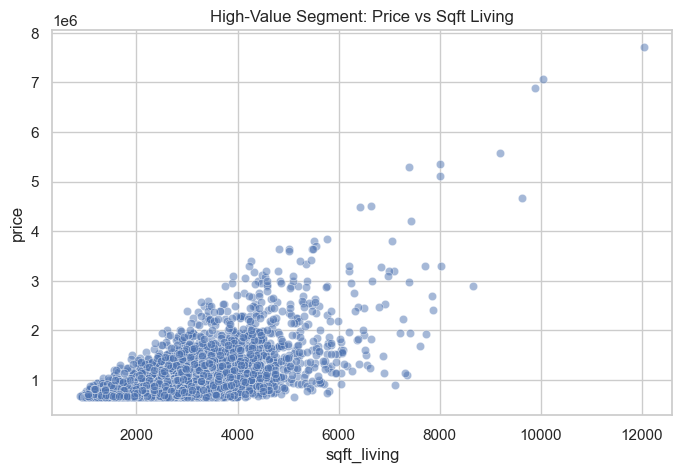

In [130]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=high_value.sample(min(len(high_value), 5000), random_state=RANDOM_STATE),
                x="sqft_living", y="price", alpha=0.5)
plt.title("High-Value Segment: Price vs Sqft Living")
plt.show()

**High-Value Segment Scatter Interpretation**

Within the $650K+ segment, the relationship between `sqft_living` and `price` is still positive but **more dispersed** than in the full market. Two homes of similar size (e.g., ~3,000 sqft) can differ by $1M+ in price. This tells us that once a home crosses the $650K threshold, **size alone explains less of the variance** — location, view, waterfront access, and architectural grade become relatively more important pricing factors. A dedicated segment model can learn these segment-specific weightings more effectively than a single model trained on all price levels.

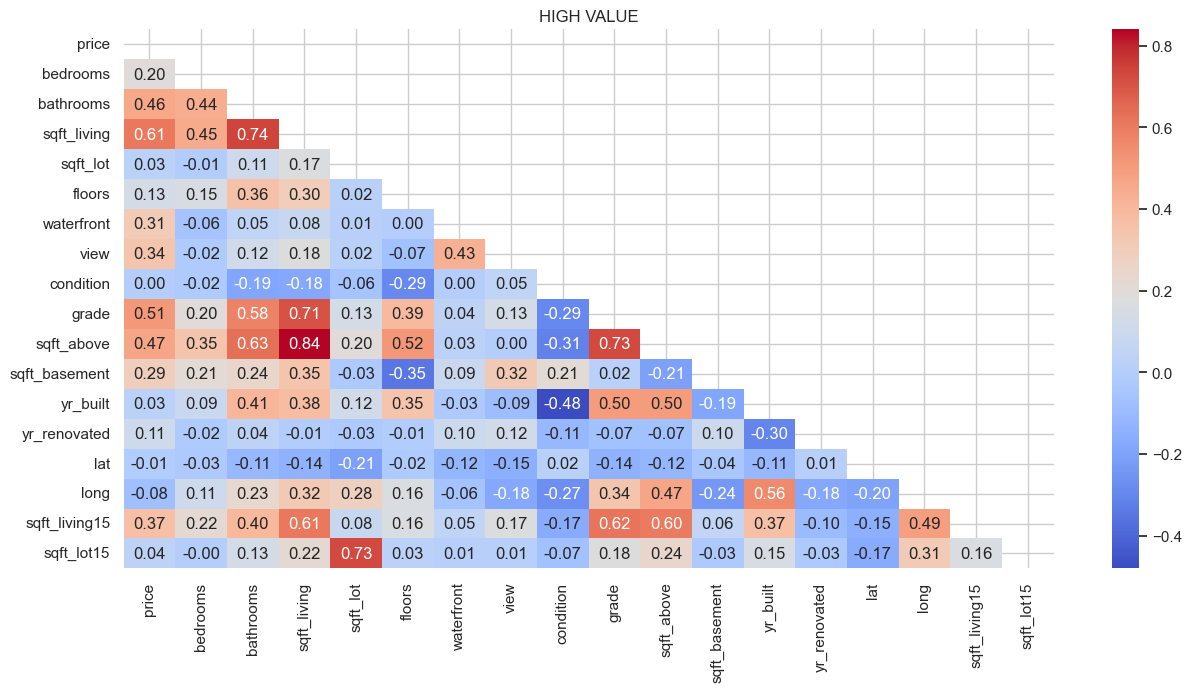

In [133]:
correlation_matrix = round(high_value[high_value.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("HIGH VALUE")
plt.show()

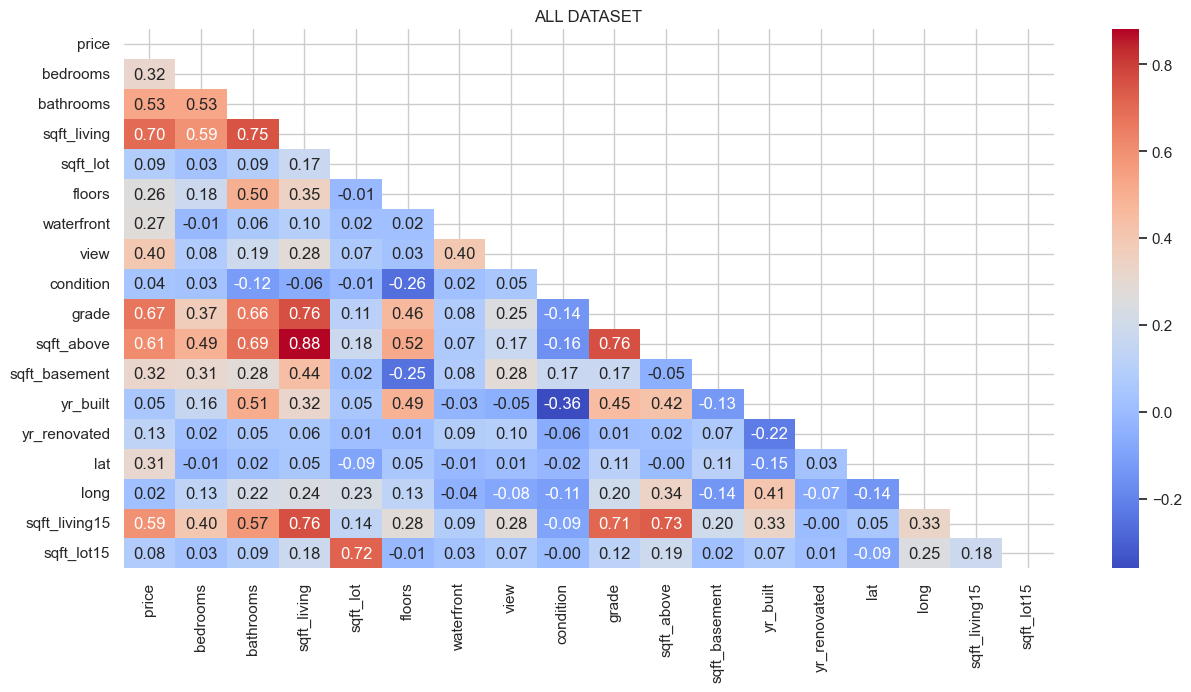

In [135]:
correlation_matrix = round(df_model[df_model.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

## 6. Prepare Features for Modeling

In [136]:
target_col = "price"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17289, 17)
X_test shape: (4323, 17)


**Feature Preparation Interpretation**

After one-hot encoding `zipcode`, the feature matrix expands from 20 columns to **88 columns** — the extra 68 are binary indicators, one per unique zip code area (minus the dropped reference category). This is intentional: each zip code binary column lets the model learn an independent price premium or discount for that area, capturing neighborhood-level market effects more precisely than raw lat/long coordinates alone.

The **80/20 train-test split** with `random_state=42` ensures:
- **80% (17,290 rows)** are used for fitting the models.
- **20% (4,323 rows)** are held out and never seen during training — this is our unbiased estimate of how the model generalizes to new homes.
- Fixing the seed makes all results reproducible across re-runs.

In [137]:
df_model.to_csv('../data/housing_clean.csv', index=False)